# E43 - Stochastic Basin Mechanics: the Freidlin-Wentzell round (H403-H412)

**Author**: kj · **Round**: E43 · **Campaign**: demographic-collapse (H403-H412, campaign → 412)

The norm channel of the shipped core is an AUTONOMOUS 1-D double well - its drift
`dN = -aN(N-Nlo)(N-thN)(N-Nhi) + fN` reads no other channel - so the Freidlin-Wentzell /
Eyring-Kramers machinery is *exact* for it, not a model approximation. This round adds small
dynamic noise `dN = -V'(N)dt + sqrt(2eps)dB` (per-strand, notebook-local, eps=0 bit-identical)
and asks what fluctuations buy that the deterministic campaign could not say: escape rates and
their exponential arithmetic, the most-probable transition path, pushes as action subsidies,
a noise-corrected fate map - and it closes the three pre-registered E42b reopen bars R1-R3.

**Approach**:
1. Quasipotential analytics on the exact channel (H403) and Kramers validation against
   simulation (H404), instanton vs the noisy transit corridor (H405)
2. Policy under noise: pushes as action subsidies (H406), the in/out action asymmetry as a
   collapse-ward bias (H407), big push vs annuity re-adjudicated (H412)
3. The R1-R3 closures: misery-gate identification in the straddling regime (H408), the
   measured dispersed-E Jensen gap (H409), broadcast dial-vs-switch under noise (H410)
4. The noise-corrected Seldon fate map at the data-anchored eps (H411)

**Noise anchor**: `reports/e43_epsilon_anchor.md` - central eps=5e-5/yr from detrended
marriage-rate wobble, per-region 2.2e-5 (USA) to 1.1e-4 (Poland), sweep [2e-5, 2e-4].
**Theory**: [paper digest] kramers law validity derivations Berglund, 2011 (convention
`dx = -V'dt + sqrt(2eps)dW`, exponent dV/eps); [paper digest] instanton method Grafke, 2015.

**Output**: verdicts H403-H412 → `reports/nb39_e43_verdicts.json`, four figures →
`reports/figures/nb39_*.png`.

## Imports

GPU pinned before the core import (the Leslie stack runs on torch); the shipped model is
imported from `src/` - all E43 machinery is notebook-local.

In [1]:
%load_ext autoreload
%autoreload 2

import os                                   # env + paths
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "GPU-58ae1f45-295c-681b-60ad-843265f52997")
import sys
sys.path.insert(0, "../src")

import json                                 # verdicts persistence
from pathlib import Path                    # output dirs

import numpy as np                          # numerics
import pandas as pd                         # OECD attainment anchors (E layer)
import matplotlib.pyplot as plt             # figures
from scipy.integrate import quad, solve_ivp # quasipotential quadrature + instanton ODE
from scipy.optimize import brentq           # tilted-well roots
from scipy.special import ndtri             # LHS initial spreads (mirrors run_cal)
from rich import print as rprint            # rich console output

from sci_demographic_collapse import emergent as em   # the shipped calibrated core

2026-07-11 15:31:34.880 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
NOISE_SEED = 1234   # per-run EM noise streams are seeded from this

## Configuration

The double-well constants come from the live core (no copied literals); the noise anchor
comes from the E43 epsilon-anchor analysis; the E/W-layer parameters are the E42 values
carried forward for the R1-R3 closures.

In [3]:
REGIONS = list(em.REAL)
YEARS = 102                                   # 2023 -> 2125
_base = em.EmergentModel("../data/raw/unwpp")
PN = {k: _base.P[k] for k in ("aN", "Nlo", "thN", "Nhi", "lam_rho")}   # live core constants
A_, B_, C_ = PN["Nlo"], PN["thN"], PN["Nhi"]

# --- noise anchor: reports/e43_epsilon_anchor.md (marriage-rate residual wobble) -------------
EPS0 = 5e-5                                   # central: sigma_N_yr ~ 0.0098 -> eps = sigma^2/2
EPS_REG = {"USA": 2.2e-5, "Japan": 3.1e-5, "Italy": 4.2e-5, "Israel": 4.3e-5,
           "France": 5.4e-5, "Germany": 6.4e-5, "Korea": 8.5e-5, "Poland": 1.1e-4}
EPS_SWEEP = (2e-5, 5e-5, 1e-4, 2e-4)          # the anchored decade-wide range

# --- E42 E/W layer parameters carried forward (NB38 config, unchanged values) ----------------
E_CEIL = 0.85
ATT = pd.read_csv("../data/raw/oecd/tertiary_attainment_women_25_34.csv")
ISO = {"USA": "USA", "France": "FRA", "Germany": "DEU", "Italy": "ITA",
       "Japan": "JPN", "Korea": "KOR", "Poland": "POL", "Israel": "ISR"}
_ISO_COL = "iso3" if "iso3" in ATT.columns else ATT.columns[0]
_VAL_COL = [c for c in ATT.columns if ATT[c].dtype.kind == "f"][-1]
_YR_COL = [c for c in ATT.columns if "year" in c.lower()][0]
E0_ATT, E_RATE = {}, {}
for nm, iso in ISO.items():
    g = ATT[ATT[_ISO_COL] == iso].sort_values(_YR_COL)
    yrs, vals = g[_YR_COL].to_numpy(float), g[_VAL_COL].to_numpy(float) / 100.0
    E0_ATT[nm] = float(vals[-1])
    gap = np.clip(E_CEIL - vals, 1e-3, None)
    r = -np.polyfit(yrs, np.log(gap), 1)[0] if len(vals) > 3 else 0.02
    E_RATE[nm] = float(np.clip(r, 0.0, 0.05))
P_EW = dict(kE=0.04, race=0.5, sigE=0.08, YRS_PER_SHARE=4.5,
            kW=0.5, aWS=1.2, lamLA=2.25, W_floor=-0.15)
PEN = {"USA": -0.127, "Korea": -0.10, "Japan": -0.09, "Italy": -0.06,
       "Poland": -0.05, "Germany": -0.04, "Israel": -0.02, "France": -0.01}
EQ = {"Korea": 0.25, "Japan": 0.30, "Italy": 0.35, "Poland": 0.40,
      "Germany": 0.55, "Israel": 0.55, "USA": 0.65, "France": 0.70}

rprint("[bold]E43 configuration[/bold]")
rprint(f"  [bold]Double well[/bold]  aN={PN['aN']}  wells ({A_}, {C_})  tip {B_}  lam_rho={PN['lam_rho']}")
rprint(f"  [bold]eps anchor[/bold]  central {EPS0:.1e}  region range [{min(EPS_REG.values()):.1e}, {max(EPS_REG.values()):.1e}]")
rprint(f"  [bold]eps per region[/bold]  " + "  ".join(f"{n}:{v:.1e}" for n, v in EPS_REG.items()))
rprint(f"  [bold]E42 layer[/bold]  W_floor {P_EW['W_floor']}  lamLA {P_EW['lamLA']}  T_adapt {1/P_EW['kW']:.0f}y")

E43 configuration

Double well  aN=2.5  wells (0.14, 0.42)  tip 0.25  lam_rho=0.3

eps anchor  central 5.0e-05  region range [2.2e-05, 1.1e-04]

eps per region  USA:2.2e-05  Japan:3.1e-05  Italy:4.2e-05  Israel:4.3e-05  France:5.4e-05  Germany:6.4e-05  
Korea:8.5e-05  Poland:1.1e-04

E42 layer  W_floor -0.15  lamLA 2.25  T_adapt 2y

## The models - NoiseModel and the ported E42 layer

`NoiseModel` adds per-strand Euler-Maruyama noise to the norm channel through the effective
force vector: `f[5] += sqrt(2 eps/dt) xi` so each substep receives exactly `sqrt(2 eps dt) xi`.
At `eps = 0` the force passes through untouched - bit identity by code path. `E42L` is the E42
E/W layer (NB38's `EWModel`) ported on top of it for the R1-R3 closures; its provenance is
proven below by reproducing NB38's recorded Germany mirror-shock number, not assumed (the
E40-A8 copied-code lesson). One single substep counter serves both layers.

In [4]:
class NoiseModel(em.EmergentModel):
    """E43 notebook-local: per-strand dynamic noise on N. eps=0 -> bit-identical to the core."""

    def __init__(self, *a, eps=0.0, noise_seed=NOISE_SEED, **kw):
        super().__init__(*a, **kw)
        self.eps = float(eps)
        self.noise_seed = noise_seed

    def run_ens(self, region, *a, **kw):
        self._nrng = np.random.default_rng(self.noise_seed)
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        if self.eps > 0.0:
            f = list(force) + [0.0] * (7 - len(force))
            f[5] = f[5] + np.sqrt(2.0 * self.eps / dt) * self._nrng.standard_normal(st.shape[0])
            force = f
        return super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)


class E42L(NoiseModel):
    """The E42 E/W layer (NB38 EWModel) ported verbatim on top of NoiseModel.

    Loadings all default 0 -> the layer is inert and the class reduces to NoiseModel;
    with eps=0 as well it is bit-identical to the shipped core. Equivalence to NB38 is
    PROVEN below (Germany mirror-shock asymmetry reproduced against the recorded value).
    `record_Ewire`/`replay_Ewire` support the H409 mean-field surrogate (R2)."""

    DEFAULTS = dict(gEtau=0.0, gEdot=0.0, gES=0.0, gErv=0.0,
                    gWrv=0.0, gWdot=0.0, gWN=0.0, fE=0.0, fW=0.0, fWh=0.0, pen_scale=0.0)

    def __init__(self, *a, ew=None, record_Ewire=False, replay_Ewire=None, **kw):
        super().__init__(*a, **kw)
        self.EW = dict(P_EW)
        self.EW.update(self.DEFAULTS)
        if ew:
            self.EW.update(ew)
        self.record_Ewire, self.replay_Ewire = record_Ewire, replay_Ewire
        self.ewire = []

    def run_ens(self, region, *a, **kw):
        K = kw.get("K", 64)
        e = self.EW
        z = (np.arange(K) + 0.5) / K - 0.5
        rng = np.random.default_rng(kw.get("seed", 0) + 7)
        self._E = np.clip(E0_ATT[region] + e["sigE"] * 2.0 * z[rng.permutation(K)], 0.02, 0.98)
        self._W = np.zeros(K)
        self._hab = np.zeros(K)
        self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        self._dEdt, self._dWdt = np.zeros(K), np.zeros(K)
        self._sub, self._E0r, self._rEr = 0, E0_ATT[region], E_RATE[region]
        self._penr, self._eqr = PEN[region], EQ[region]
        self.ewire = []
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        e = self.EW
        loaded = any(e[k] != 0.0 for k in ("gEtau", "gEdot", "gES", "gErv", "gWrv", "gWdot", "gWN"))
        if loaded or self.replay_Ewire is not None:
            f = list(force) + [0.0] * (7 - len(force))
            dE, dEr = self._E - self._E0r, self._dEdt
            ew_tau = e["gEtau"] * e["YRS_PER_SHARE"] * dE + e["gEdot"] * np.clip(dEr, 0, None) * 100
            if self.record_Ewire:
                self.ewire.append(float(np.mean(ew_tau)))
            if self.replay_Ewire is not None:
                ew_tau = ew_tau + self.replay_Ewire[min(self._sub, len(self.replay_Ewire) - 1)]
            f[3] = f[3] + ew_tau
            f[0] = f[0] + e["gES"] * dE
            f[4] = f[4] + e["gErv"] * dE * (1.0 - self._eqr / 0.55)
            gate = np.clip(e["W_floor"] - self._W, 0, None)
            asym = e["lamLA"] * np.clip(-self._dWdt, 0, None) - np.clip(self._dWdt, 0, None)
            f[4] = f[4] + e["gWrv"] * gate + e["gWdot"] * asym
            f[5] = f[5] - e["gWN"] * float(np.mean(self._W))
            force = f
        elif self.record_Ewire:
            self.ewire.append(0.0)
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        S, rv = out[:, 4], out[:, 1]
        Esec = E_CEIL - (E_CEIL - self._E0r) * np.exp(-self._rEr * 100 * tn)
        Etgt = Esec + e["race"] * np.clip(self._E.mean() - self._E, 0, None) + e["fE"]
        self._E = np.clip(self._E + dt * e["kE"] * (Etgt - self._E), 0.02, 0.98)
        Wtgt = e["aWS"] * (S - em.S0[nm]) + e["fW"] + e["pen_scale"] * self._penr * (1 - rv)
        self._hab = self._hab + dt * e["kW"] * (e["fWh"] - self._hab)
        self._W = self._W + dt * e["kW"] * (Wtgt - self._W) + dt * (e["fWh"] - self._hab)
        self._sub += 1
        if self._sub % 4 == 0:  # a model year turned: REALIZED yearly derivatives (E40 lesson)
            self._dEdt = self._E - self._Eprev
            self._dWdt = self._W - self._Wprev
            self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        return out, dtau


class LinModel(E42L):
    """Two-sided linear W coupling - the strawman the misery gate must beat (NB38 H400)."""

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        assert self.eps == 0.0, "LinModel bypasses NoiseModel's injection - eps>0 unsupported"
        e = self.EW
        f = list(force) + [0.0] * (7 - len(force))
        f[4] = f[4] - e["gWlin"] * self._W
        out, dtau = em.EmergentModel._estep_vec(self, nm, st, f, tn, dep_pen, A_lag, dt)
        S = out[:, 4]
        self._W = self._W + dt * e["kW"] * (e["aWS"] * (S - em.S0[nm]) - self._W)
        self._sub += 1
        if self._sub % 4 == 0:
            self._dWdt = self._W - self._Wprev
            self._Wprev = self._W.copy()
        return out, dtau


def cal(model, nm, force=None):
    return model.run_cal(nm, force=force) if force else model.run_cal(nm)


VERDICTS = {}


def record(h, title, verdict, metric, note):
    VERDICTS[h] = dict(title=title, verdict=verdict, metric=metric, note=note)
    color = {"SUPPORTED": "green", "PARTIAL": "yellow", "REFUTED": "red"}[verdict]
    rprint(f"[bold {color}]{h} {verdict}[/bold {color}] - {title}")
    rprint(f"   metric: {metric}")
    rprint(f"   {note}")

## Baseline preservation - the hard gate

Both halves asserted (the E42 review lesson): `eps=0`, loadings-off must reproduce the
calibrated core bit-for-bit AND hold the 2023 anchor for all 8 regions.

In [5]:
base = em.EmergentModel("../data/raw/unwpp")
ew0 = E42L("../data/raw/unwpp")          # eps=0, all loadings 0
BASE = {nm: cal(base, nm) for nm in REGIONS}
worst, worst_a = 0.0, 0.0
for nm in REGIONS:
    d = float(np.max(np.abs(BASE[nm]["TFR"] - cal(ew0, nm)["TFR"])))
    worst = max(worst, d)
    a2023 = abs(BASE[nm]["TFR"][0] - em.REAL[nm][0])
    worst_a = max(worst_a, a2023)
    rprint(f"  {nm:8s} max|dTFR| = {d:.2e}   |TFR2023 - real| = {a2023:.2e}")
assert worst == 0.0, f"baseline preservation FAILED: {worst}"
assert worst_a < 5e-4, f"2023 anchor regression: {worst_a:.2e} >= 5e-4"  # the E41 bar
rprint("[bold green]PASS[/bold green] - eps=0 loadings-off E42L is bit-identical to the shipped core, 8/8, anchors held")

USA      max|dTFR| = 0.00e+00   |TFR2023 - real| = 6.32e-05

France   max|dTFR| = 0.00e+00   |TFR2023 - real| = 6.50e-05

Germany  max|dTFR| = 0.00e+00   |TFR2023 - real| = 5.13e-05

Italy    max|dTFR| = 0.00e+00   |TFR2023 - real| = 2.19e-06

Japan    max|dTFR| = 0.00e+00   |TFR2023 - real| = 1.33e-05

Korea    max|dTFR| = 0.00e+00   |TFR2023 - real| = 1.32e-05

Poland   max|dTFR| = 0.00e+00   |TFR2023 - real| = 3.25e-05

Israel   max|dTFR| = 0.00e+00   |TFR2023 - real| = 1.92e-05

PASS - eps=0 loadings-off E42L is bit-identical to the shipped core, 8/8, anchors held

### E42-layer equivalence check (the A8 mitigation)

The ported layer must reproduce NB38's recorded Germany mirror-shock asymmetry (gated 1.03
vs linear 1.00) before any R1-R3 statement rides on it.

In [6]:
down = lambda yr: [-0.20, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7  # noqa: E731
up = lambda yr: [+0.20, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7      # noqa: E731


def mirror(model_factory, region):
    m = model_factory(); b = cal(m, region)["TFR"]
    m = model_factory(); dn = cal(m, region, force=down)["TFR"] - b
    m = model_factory(); upn = cal(m, region, force=up)["TFR"] - b
    loss = float(-dn[5:25].min()); gain = float(max(upn[5:25].max(), 1e-9))
    return loss / gain


asym_de = mirror(lambda: E42L("../data/raw/unwpp", ew=dict(gWrv=0.4, gWdot=0.03)), "Germany")
def _lin():
    m = LinModel("../data/raw/unwpp"); m.EW["gWlin"] = 0.20; return m
asym_de_lin = mirror(_lin, "Germany")
rprint(f"  ported layer Germany: gated {asym_de:.2f} vs linear {asym_de_lin:.2f}  (NB38 record: 1.03 vs 1.00)")
assert abs(asym_de - 1.03) <= 0.02 and abs(asym_de_lin - 1.00) <= 0.02, "E42-layer equivalence FAILED"
rprint("[bold green]PASS[/bold green] - the ported E42 layer reproduces NB38's recorded numbers")

ported layer Germany: gated 1.03 vs linear 1.00  (NB38 record: 1.03 vs 1.00)

PASS - the ported E42 layer reproduces NB38's recorded numbers

## Act I - The exact machinery (H403-H405)

### H403 - the quasipotential is exact, well-binary, and collapse-tilted

**Hypothesis**: the norm channel admits an exact quasipotential treatment (autonomous 1-D
gradient flow), and its structure ranks the regions' basin stability - pre-registered as
"Korea's escape action is the campaign's largest".
**Bars**: (i) analytic V matches drift quadrature < 1e-10; (ii) the in/out action asymmetry
is real (falling into the trap materially cheaper than escaping); (iii) the pre-registered
ranking sub-bar: Korea carries the largest eps-scaled escape action among the trapped regions.

In [7]:
def Vpot(N, fN=0.0):
    """V(N) = aN * int (N-a)(N-b)(N-c) dN - fN*N, so drift = -V'(N)."""
    s1, s2, s3 = A_ + B_ + C_, A_ * B_ + A_ * C_ + B_ * C_, A_ * B_ * C_
    return PN["aN"] * (N**4 / 4 - s1 * N**3 / 3 + s2 * N**2 / 2 - s3 * N) - fN * N


def Vpp(N):
    s1, s2 = A_ + B_ + C_, A_ * B_ + A_ * C_ + B_ * C_
    return PN["aN"] * (3 * N**2 - 2 * s1 * N + s2)


drift = lambda N, fN=0.0: -PN["aN"] * (N - A_) * (N - B_) * (N - C_) + fN  # noqa: E731

# bar (i): the analytic V against numerical quadrature of the live drift
qerr = max(abs(Vpot(x) - (-quad(lambda u: drift(u), 0.0, x)[0])) for x in np.linspace(0.02, 0.98, 25))
DV_OUT = float(Vpot(B_) - Vpot(C_))   # escape barrier (trap -> tip)
DV_IN = float(Vpot(B_) - Vpot(A_))    # fall-in barrier (low well -> tip)
ASYM_V = DV_OUT / DV_IN
PREF_OUT = 2 * np.pi / np.sqrt(Vpp(C_) * abs(Vpp(B_)))   # Eyring-Kramers prefactors
PREF_IN = 2 * np.pi / np.sqrt(Vpp(A_) * abs(Vpp(B_)))
rprint(f"  quadrature error {qerr:.1e};  dV_out {DV_OUT:.3e}  dV_in {DV_IN:.3e}  asymmetry x{ASYM_V:.2f}")
rprint(f"  curvatures V''(lo)={Vpp(A_):.4f} V''(tip)={Vpp(B_):+.4f} V''(hi)={Vpp(C_):.4f};  prefactors out {PREF_OUT:.0f}y in {PREF_IN:.0f}y")

QP = {}
for nm in REGIONS:
    n0, eps = em.NORM0[nm], EPS_REG[nm]
    trapped = n0 > B_
    dV = DV_OUT if trapped else DV_IN
    pref = PREF_OUT if trapped else PREF_IN
    QP[nm] = dict(N0=n0, trapped=bool(trapped), eps=eps, action_scaled=dV / eps,
                  tau_kramers=float(pref * np.exp(dV / eps)))
    rprint(f"  {nm:8s} {'TRAP' if trapped else 'low '}  eps {eps:.1e}  dV/eps {dV/eps:6.1f}  Kramers tau {QP[nm]['tau_kramers']:.3g} y")

trapped_rank = sorted([nm for nm in REGIONS if QP[nm]["trapped"]], key=lambda n: -QP[n]["action_scaled"])
ok_i, ok_ii = qerr < 1e-10, 3.0 <= ASYM_V <= 3.5
ok_iii = trapped_rank[0] == "Korea"
verdict = "SUPPORTED" if (ok_i and ok_ii and ok_iii) else ("PARTIAL" if (ok_i and ok_ii) else "REFUTED")
record("H403", "the quasipotential is exact, well-binary, and collapse-tilted", verdict,
       f"quad err {qerr:.1e}; dV_out/dV_in = x{ASYM_V:.2f}; eps-scaled trapped ranking {trapped_rank}",
       "The channel is an exact 1-D gradient double well; the barrier is WELL-BINARY (NORM0 is "
       "snapped to the wells, so all trapped regions share one raw action) and falling into the "
       f"trap costs x{ASYM_V:.1f} LESS action than escaping - the potential itself is collapse-tilted. "
       "Region resolution enters only through the per-region noise anchor, and there the "
       f"pre-registered ranking sub-bar {'holds' if ok_iii else 'FAILS'}: in eps-scaled units "
       f"{trapped_rank[0]} carries the deepest effective trap"
       + ("" if ok_iii else " (quiet-wobble Japan, not Korea - the anchor, not the barrier, decides)")
       + ".")

quadrature error 8.3e-17;  dV_out 3.992e-04  dV_in 1.248e-04  asymmetry x3.20

curvatures V''(lo)=0.0770 V''(tip)=-0.0468 V''(hi)=0.1190;  prefactors out 84y in 105y

USA      low   eps 2.2e-05  dV/eps    5.7  Kramers tau 3.04e+04 y

France   low   eps 5.4e-05  dV/eps    2.3  Kramers tau 1.06e+03 y

Germany  low   eps 6.4e-05  dV/eps    1.9  Kramers tau 736 y

...

Poland   TRAP  eps 1.1e-04  dV/eps    3.6  Kramers tau 3.17e+03 y

Israel   low   eps 4.3e-05  dV/eps    2.9  Kramers tau 1.91e+03 y

H403 PARTIAL - the quasipotential is exact, well-binary, and collapse-tilted

metric: quad err 8.3e-17; dV_out/dV_in = x3.20; eps-scaled trapped ranking ['Japan', 'Italy', 'Korea', 'Poland']

The channel is an exact 1-D gradient double well; the barrier is WELL-BINARY (NORM0 is snapped to the wells, so 
all trapped regions share one raw action) and falling into the trap costs x3.2 LESS action than escaping - the 
potential itself is collapse-tilted. Region resolution enters only through the per-region noise anchor, and there 
the pre-registered ranking sub-bar FAILS: in eps-scaled units Japan carries the deepest effective trap 
(quiet-wobble Japan, not Korea - the anchor, not the barrier, decides).

### H404 - Eyring-Kramers validates against simulation

**Hypothesis**: simulated mean first-passage times obey the Kramers law.
**Bars**: exponential slope of log-MFPT vs 1/eps within 15% of dV_out; full-transit prefactor
ratio stable across the grid; dt-halving moves the measured MFPT < 15% (EM bias check).

In [8]:
def mfpt_1d(eps, M=4000, dt=0.25, x0=C_, absorb=A_, Tmax=None, seed=7, fN=0.0, record_paths=False):
    """Vectorised Euler-Maruyama first-passage on the bare channel (absorbing at `absorb`)."""
    rng = np.random.default_rng(seed)
    if Tmax is None:
        Tmax = 60_000
    x = np.full(M, float(x0)); t_hit = np.full(M, np.nan); alive = np.ones(M, bool)
    paths = [x.copy()] if record_paths else None
    for i in range(int(Tmax / dt)):
        if not alive.any():
            break
        xa = x[alive]
        xa = np.clip(xa + dt * drift(xa, fN) + np.sqrt(2 * eps * dt) * rng.standard_normal(xa.size), 0.0, 1.0)
        x[alive] = xa
        hit = alive.copy(); hit[alive] = xa <= absorb if absorb < x0 else xa >= absorb
        t_hit[hit] = (i + 1) * dt
        alive &= ~hit
        if record_paths:
            paths.append(x.copy())
    return t_hit, (np.array(paths) if record_paths else None)


EPS_VAL = (2e-4, 1.33e-4, 1e-4)
MF = {}
for eps in EPS_VAL:
    t_hit, _ = mfpt_1d(eps)
    done = np.isfinite(t_hit)
    MF[eps] = dict(mfpt=float(np.nanmean(t_hit[done])), esc=float(done.mean()),
                   theo=float(PREF_OUT * np.exp(DV_OUT / eps)))
    rprint(f"  eps={eps:.2e}  MFPT {MF[eps]['mfpt']:8.1f}y ({MF[eps]['esc']*100:.0f}% escaped)  Kramers {MF[eps]['theo']:8.1f}y  ratio {MF[eps]['mfpt']/MF[eps]['theo']:.3f}")

inv = np.array([1 / e for e in EPS_VAL]); lnt = np.array([np.log(MF[e]["mfpt"]) for e in EPS_VAL])
slope = float(np.polyfit(inv, lnt, 1)[0])
ratios = [MF[e]["mfpt"] / MF[e]["theo"] for e in EPS_VAL]
t_half, _ = mfpt_1d(2e-4, M=2000, dt=0.125, seed=11)
mf_half = float(np.nanmean(t_half[np.isfinite(t_half)]))
dt_shift = abs(mf_half - MF[2e-4]["mfpt"]) / MF[2e-4]["mfpt"]
rprint(f"  slope {slope:.3e} vs dV_out {DV_OUT:.3e} ({abs(slope-DV_OUT)/DV_OUT*100:.1f}% off);  ratio spread {min(ratios):.2f}-{max(ratios):.2f};  dt-halving shift {dt_shift*100:.1f}%")
ok = abs(slope - DV_OUT) / DV_OUT <= 0.15 and (max(ratios) - min(ratios)) / np.mean(ratios) <= 0.15 and dt_shift <= 0.15
record("H404", "Eyring-Kramers validates against simulation", "SUPPORTED" if ok else "PARTIAL",
       f"slope {slope:.3e} vs dV {DV_OUT:.3e}; prefactor ratio {np.mean(ratios):.2f} (flat); dt-halving {dt_shift*100:.1f}%",
       "The exponential arithmetic is the machine's own: the measured log-slope reproduces the "
       "barrier and the prefactor ratio is a stable O(1) constant (finite-barrier + EM-dt "
       "corrections per the Berglund digest), so Kramers theory can replace brute-force rare-event "
       "simulation everywhere the barrier is large." if ok else
       "A validation bar missed - theory substitution is not licensed at this dt/eps range.")

eps=2.00e-04  MFPT    718.2y (100% escaped)  Kramers    619.9y  ratio 1.159

eps=1.33e-04  MFPT   2004.7y (100% escaped)  Kramers   1694.3y  ratio 1.183

eps=1.00e-04  MFPT   5325.5y (100% escaped)  Kramers   4561.8y  ratio 1.167

slope 4.007e-04 vs dV_out 3.992e-04 (0.4% off);  ratio spread 1.16-1.18;  dt-halving shift 1.1%

H404 SUPPORTED - Eyring-Kramers validates against simulation

metric: slope 4.007e-04 vs dV 3.992e-04; prefactor ratio 1.17 (flat); dt-halving 1.1%

The exponential arithmetic is the machine's own: the measured log-slope reproduces the barrier and the prefactor
ratio is a stable O(1) constant (finite-barrier + EM-dt corrections per the Berglund digest), so Kramers theory can
replace brute-force rare-event simulation everywhere the barrier is large.

### H405 - the instanton is the observed transition corridor

**Hypothesis**: noisy escape paths concentrate around the most-probable path (the
time-reversed anti-gradient climb, Berglund eq 2.11 / Grafke).
**Bar**: the median noisy transit stays inside the local 2-sigma tube sqrt(eps/|V''|) around
the instanton for >= 90% of the transit (evaluated away from the saddle where the tube blows up).

In [9]:
EPS_I = 2e-4
t_hit, paths = mfpt_1d(EPS_I, M=1200, absorb=A_ + 0.01, seed=13, record_paths=True)
# per-walker transit segment: last departure from the trap-well shoulder -> first tip crossing
segs = []
for j in range(paths.shape[1]):
    pj = paths[:, j]
    below = np.where(pj <= B_)[0]
    if below.size == 0:
        continue
    t_tip = below[0]
    above = np.where(pj[:t_tip] >= C_ - 0.01)[0]
    t_dep = above[-1] if above.size else 0
    if t_tip - t_dep >= 8:
        segs.append(pj[t_dep:t_tip + 1])
L = int(np.median([len(s) for s in segs]))
grid = np.linspace(0, 1, L)
aligned = np.array([np.interp(grid, np.linspace(0, 1, len(s)), s) for s in segs])
med = np.median(aligned, axis=0)

# the instanton: the time-reversed relaxation (phi_dot = +V' = -drift), descending from the
# trap-well shoulder to just past the tip; terminated a hair above the saddle where the
# reversed flow slows logarithmically
def _ev(t, y):
    return y[0] - (B_ + 1e-4)
_ev.terminal = True
sol = solve_ivp(lambda t, y: [-drift(y[0])], (0, 100_000), [C_ - 0.01],
                events=_ev, max_step=0.25, rtol=1e-8)
inst = np.interp(grid, sol.t / sol.t[-1], sol.y[0])
tube = 2 * np.sqrt(EPS_I / np.clip(np.abs(Vpp(inst)), 0.02, None))
mask = np.abs(Vpp(inst)) > 0.02
inside = float(np.mean(np.abs(med - inst)[mask] <= tube[mask]))
rprint(f"  transits {len(segs)}; median-vs-instanton inside 2-sigma tube: {inside*100:.0f}% (away from saddle)")
ok = inside >= 0.90
record("H405", "the instanton is the observed transition corridor", "SUPPORTED" if ok else "PARTIAL",
       f"{len(segs)} transits at eps={EPS_I:.0e}; median path inside the 2-sigma tube {inside*100:.0f}% of the transit",
       "The trajectory path-integral machinery is live: escapes do not wander - they concentrate "
       "along the time-reversed relaxation path, so the MOST-PROBABLE collapse/recovery route is "
       "computable in closed form and the corridor width is sqrt(eps/|V''|)." if ok else
       "The corridor bar missed - path concentration is weaker than the LDP asymptotics at this eps.")

transits 1200; median-vs-instanton inside 2-sigma tube: 100% (away from saddle)

H405 SUPPORTED - the instanton is the observed transition corridor

metric: 1200 transits at eps=2e-04; median path inside the 2-sigma tube 100% of the transit

The trajectory path-integral machinery is live: escapes do not wander - they concentrate along the time-reversed
relaxation path, so the MOST-PROBABLE collapse/recovery route is computable in closed form and the corridor width 
is sqrt(eps/|V''|).

## Act II - Policy under noise (H406, H407, H412)

### H406 - a push is an action subsidy

**Hypothesis**: a deterministic push that cannot cross the barrier still buys real escape
probability by LOWERING the action; the (fN, eps) plane splits along tau(fN, eps) ~ horizon.
**Bar**: the measured 50%-escape frontier fN*(eps) at the 100y horizon within 15% (in fN) of
the Kramers prediction, for every eps in the anchored sweep; plus a coupled-core spot check
within a factor 2 of the 1-D prediction.

In [10]:
# A pro-family push must LOWER N, so an escape-assisting tilt is fN = -s with push
# strength s >= 0 (f[5] raises the childfree-ideal norm; the broadcast wire's sign in E42
# already carried this convention). The prototype's first fold estimate (+0.0017) was the
# FALL-IN fold - the direction that erases the low well.
def tilted(s):
    """Roots and escape barrier of the well tilted by a pro-family push fN = -s."""
    xs = np.linspace(0.02, 0.98, 2000)
    d = drift(xs, -s)
    idx = np.where(np.diff(np.sign(d)) != 0)[0]
    if len(idx) < 3:
        return None                      # tip and trap well merged: past the escape fold
    lo, tip, hi = (brentq(lambda x: drift(x, -s), xs[i], xs[i + 1]) for i in idx[:3])
    return dict(lo=lo, tip=tip, hi=hi, dV=float(Vpot(tip, -s) - Vpot(hi, -s)))


lo_f, hi_f = 0.0, 0.02
for _ in range(40):
    mid = 0.5 * (lo_f + hi_f)
    t = tilted(mid)
    if t is None or t["dV"] <= 1e-9:
        hi_f = mid
    else:
        lo_f = mid
FOLD = 0.5 * (lo_f + hi_f)
rprint(f"  escape fold (the trap barrier vanishes) at push s* = {FOLD:.5f} (fN = -s*) - far "
       f"below catalogue-scale norm forcings, so E25+ deterministic norm levers were all SUPER-fold tips")
HORIZON = 100.0
FRONT = {}
for eps in EPS_SWEEP:
    # theory: P(esc in T) = 1 - exp(-T/tau) = 0.5  <=>  dV(fN) = eps * ln(T / (ln2 * prefactor))
    target = eps * np.log(HORIZON / (np.log(2) * PREF_OUT))
    f_theo = brentq(lambda f: tilted(f)["dV"] - target, 0.0, FOLD * 0.999) \
        if tilted(0.0)["dV"] > target else 0.0
    # measured: bisect on the simulated 100y escape probability (push = fN < 0)
    def p_esc(f, eps=eps):
        t_hit, _ = mfpt_1d(eps, M=1500, Tmax=HORIZON, fN=-f, seed=17, absorb=B_)
        return float(np.isfinite(t_hit).mean())
    lo_f, hi_f = 0.0, FOLD
    for _ in range(9):
        mid = 0.5 * (lo_f + hi_f)
        if p_esc(mid) < 0.5:
            lo_f = mid
        else:
            hi_f = mid
    f_meas = 0.5 * (lo_f + hi_f)
    FRONT[eps] = dict(theo=float(f_theo), meas=float(f_meas))
    rprint(f"  eps={eps:.1e}  50%-escape fN: theory {f_theo:.4f}  measured {f_meas:.4f}  ({abs(f_meas-f_theo)/max(f_theo,1e-6)*100 if f_theo>0 else 0:.0f}% off)")

errs = [abs(v["meas"] - v["theo"]) / max(v["theo"], 1e-6) for v in FRONT.values() if v["theo"] > 0]
# coupled-core spot check: Korea at its anchored eps, push at 90% of the frontier fN
f_spot = 0.9 * FRONT[1e-4]["meas"]
nz = NoiseModel("../data/raw/unwpp", eps=EPS_REG["Korea"])
r_spot = nz.run_cal("Korea", force=lambda yr: [0, 0, 0, 0, 0, -f_spot, 0], return_dist=True)
t_1d, _ = mfpt_1d(EPS_REG["Korea"], M=4000, Tmax=102, fN=-f_spot, seed=19, absorb=B_)
p_1d = float(np.isfinite(t_1d).mean())
p_coupled = float((r_spot["dist_end"]["N"] < B_).mean())   # strand crossing fraction - SAME units
d_spot = float(r_spot["TFR"][-1] - BASE["Korea"]["TFR"][-1])
rprint(f"  coupled spot (Korea, push s={f_spot:.4f}, eps={EPS_REG['Korea']:.1e}): strand crossing "
       f"fraction {p_coupled:.2f} vs 1-D century escape prob {p_1d:.2f} (dTFR2125 {d_spot:+.4f})")
spot_ok = 0.5 * p_1d <= p_coupled <= 2.0 * p_1d   # the pre-registered factor-2 check, adjudicated
ok = max(errs) <= 0.15 and spot_ok
record("H406", "a push is an action subsidy", "SUPPORTED" if ok else "PARTIAL",
       f"50%-frontier errors {['%.0f%%' % (e*100) for e in errs]}; escape fold at push s*={FOLD:.4f}; "
       f"coupled Korea spot crossing {p_coupled:.2f} vs 1-D {p_1d:.2f} (factor-2 check {'PASS' if spot_ok else 'FAIL'})",
       "Sub-fold pushes buy escape probability exactly as the tilted action predicts: the "
       "(push, noise) plane splits along tau(fN,eps) ~ horizon, so policy sizing becomes barrier "
       "arithmetic - a push is priced by the action it removes, not the TFR it moves on day one."
       if ok else "The frontier holds structurally (it exists, is monotone in eps, and matches "
       "at both sweep ends) but the mid-sweep misses the 15% bar - the Kramers asymptotics are "
       "marginal where the target barrier sits at dV ~ O(eps) near the fold (the Berglund "
       "validity caveat). The action-subsidy picture stands; its arithmetic is ~25%-accurate "
       "at the century horizon.")

escape fold (the trap barrier vanishes) at push s* = 0.00368 (fN = -s*) - far below catalogue-scale norm 
forcings, so E25+ deterministic norm levers were all SUPER-fold tips

eps=2.0e-05  50%-escape fN: theory 0.0033  measured 0.0037  (10% off)

eps=5.0e-05  50%-escape fN: theory 0.0031  measured 0.0037  (20% off)

eps=1.0e-04  50%-escape fN: theory 0.0027  measured 0.0033  (24% off)

eps=2.0e-04  50%-escape fN: theory 0.0021  measured 0.0019  (10% off)

coupled spot (Korea, push s=0.0030, eps=8.5e-05): strand crossing fraction 0.44 vs 1-D century escape prob 0.37 
(dTFR2125 +0.0112)

H406 PARTIAL - a push is an action subsidy

metric: 50%-frontier errors ['10%', '20%', '24%', '10%']; escape fold at push s*=0.0037; coupled Korea spot 
crossing 0.44 vs 1-D 0.37 (factor-2 check PASS)

The frontier holds structurally (it exists, is monotone in eps, and matches at both sweep ends) but the 
mid-sweep misses the 15% bar - the Kramers asymptotics are marginal where the target barrier sits at dV ~ O(eps) 
near the fold (the Berglund validity caveat). The action-subsidy picture stands; its arithmetic is ~25%-accurate at
the century horizon.

### H407 - noise is collapse-ward (the asymmetry has teeth)

**Hypothesis**: because falling in costs ~3.2x less action than escaping, equal-eps noise is
NOT neutral: low-well regions leak into the trap faster than trapped regions leak out.
**Bars**: (i) the coupled-core TFR effect of anchored noise is positive for trapped regions
and negative for low-well regions in >= 6/8; (ii) among the low-well regions, the fall-in
risk ranking follows eps (Germany/France the top-2).

In [11]:
H407 = {}
for nm in REGIONS:
    nz = NoiseModel("../data/raw/unwpp", eps=EPS_REG[nm])
    r = cal(nz, nm)
    d2125 = float(r["TFR"][-1] - BASE[nm]["TFR"][-1])
    H407[nm] = dict(dTFR2125=d2125, trapped=QP[nm]["trapped"])
    rprint(f"  {nm:8s} {'TRAP' if QP[nm]['trapped'] else 'low '}  eps {EPS_REG[nm]:.1e}  dTFR2125 {d2125:+.4f}")

# seed sensitivity on the two smallest-gain regions (round-1 review: single-seed signs)
SEEDCHK = {}
for nm in ("Japan", "Korea"):
    signs = []
    for sd in (NOISE_SEED, NOISE_SEED + 1, NOISE_SEED + 2):
        nz = NoiseModel("../data/raw/unwpp", eps=EPS_REG[nm], noise_seed=sd)
        signs.append(float(cal(nz, nm)["TFR"][-1] - BASE[nm]["TFR"][-1]))
    SEEDCHK[nm] = signs
    rprint(f"  seed check {nm}: dTFR2125 across 3 noise seeds { [round(s, 4) for s in signs] }")
sign_ok = sum((v["dTFR2125"] > 0) == v["trapped"] for v in H407.values())
low = [nm for nm in REGIONS if not QP[nm]["trapped"]]
low_rank = sorted(low, key=lambda n: H407[n]["dTFR2125"])   # most negative = highest fall-in damage
rprint(f"  sign pattern {sign_ok}/8;  low-well damage ranking {low_rank}")
ok_i = sign_ok >= 6
ok_ii = set(low_rank[:2]) == {"Germany", "France"}
verdict = "SUPPORTED" if (ok_i and ok_ii) else ("PARTIAL" if ok_i else "REFUTED")
record("H407", "noise is collapse-ward - the well asymmetry has teeth", verdict,
       f"sign pattern {sign_ok}/8; low-well damage ranking {low_rank} (bar: Germany/France top-2); "
       f"seed check Japan/Korea: { {n: [round(s, 4) for s in v] for n, v in SEEDCHK.items()} }",
       f"The x{ASYM_V:.1f} action asymmetry is not a curiosity: at the anchored per-region noise the "
       "trapped regions gain (strands leak OUT) while the low-well regions lose (strands leak IN, "
       "3x cheaper), so fluctuations alone push the system toward collapse - a ratchet the "
       "deterministic model cannot see. Where the TFR-unit damage ranking disagrees with the "
       "pre-registered Germany/France top-2 (Israel leads in TFR units), the discrepancy is the "
       "regional fertility LEVEL amplifying per-crossing damage - in probability units the "
       "ranking follows eps exactly (the H411 map)." if ok_i else
       "The sign pattern failed its bar - the within-well response dominates the leak at this eps.")

USA      low   eps 2.2e-05  dTFR2125 -0.0030

France   low   eps 5.4e-05  dTFR2125 -0.0074

Germany  low   eps 6.4e-05  dTFR2125 -0.0077

Italy    TRAP  eps 4.2e-05  dTFR2125 +0.0013

Japan    TRAP  eps 3.1e-05  dTFR2125 +0.0010

...

seed check Korea: dTFR2125 across 3 noise seeds [0.001, 0.0009, 0.001]

sign pattern 8/8;  low-well damage ranking ['Israel', 'Germany', 'France', 'USA']

H407 PARTIAL - noise is collapse-ward - the well asymmetry has teeth

metric: sign pattern 8/8; low-well damage ranking ['Israel', 'Germany', 'France', 'USA'] (bar: Germany/France 
top-2); seed check Japan/Korea: {'Japan': [0.001, 0.0009, 0.001], 'Korea': [0.001, 0.0009, 0.001]}

The x3.2 action asymmetry is not a curiosity: at the anchored per-region noise the trapped regions gain (strands
leak OUT) while the low-well regions lose (strands leak IN, 3x cheaper), so fluctuations alone push the system 
toward collapse - a ratchet the deterministic model cannot see. Where the TFR-unit damage ranking disagrees with 
the pre-registered Germany/France top-2 (Israel leads in TFR units), the discrepancy is the regional fertility 
LEVEL amplifying per-crossing damage - in probability units the ranking follows eps exactly (the H411 map).

### H412 - big push vs annuity, re-adjudicated under noise (the norm-channel inversion)

**Hypothesis**: E38-H380's big-push law inverts ON THE NORM CHANNEL under noise + a budget
constraint: because the fold sits at a tiny fN* and the transit slows critically just above
it, a concentrated push spends its budget fighting critical slowing, while the equal-budget
PERMANENT tilt lowers the barrier forever and compounds hazard - so for every budget whose
annuity stays sub-fold, the annuity beats every push duration.
**Bars**: (i) at a low budget (annuity = 0.25 fold) the annuity's century escape probability
>= every push arm's, in both Korea and Poland; (ii) at a high sub-fold-annuity budget
(annuity = 0.8 fold) the same holds OR the winning push is one that crosses super-fold AND
completes its transit (the E38-H380 deterministic clause recovered). Scope: this adjudicates
the N channel only - E38-H380 lives on the C/S wires at catalogue magnitudes, all SUPER-fold.

In [12]:
def p_escape(eps, fseq, M=8000, seed=29):
    """Century escape probability on the bare channel under a time-dependent PUSH fseq(t) >= 0
    (applied as the pro-family tilt fN = -fseq(t))."""
    rng = np.random.default_rng(seed)
    dt = 0.25
    x = np.full(M, C_); crossed = np.zeros(M, bool)
    for i in range(int(YEARS / dt)):
        f = fseq(i * dt)
        x = np.clip(x + dt * drift(x, -f) + np.sqrt(2 * eps * dt) * rng.standard_normal(M), 0.0, 1.0)
        crossed |= x <= B_
    # first-passage (ever crossed) AND end-of-century occupancy (still out) - crossings can
    # revert after a push ends, so the verdict must hold on both metrics (round-1 review)
    return float(crossed.mean()), float((x <= B_).mean())


T_GRID = (5, 10, 20, 40, 80)
H412 = {}
for nm in ("Korea", "Poland"):
    eps = EPS_REG[nm]
    H412[nm] = {}
    for bfac in (0.25, 0.8):
        B_UD = bfac * FOLD * YEARS                 # the budget: annuity tilt = bfac * fold
        f_ann = B_UD / YEARS
        p_ann, e_ann = p_escape(eps, lambda t: f_ann)
        fp, es = {}, {}
        for T in T_GRID:
            fp[T], es[T] = p_escape(eps, lambda t, T=T: (B_UD / T) if t < T else 0.0)
        H412[nm][bfac] = dict(p_annuity=p_ann, e_annuity=e_ann, p_push=fp, e_push=es,
                              f_push={T: B_UD / T for T in T_GRID})
        rprint(f"  {nm} budget {bfac:.2f}xfold: annuity P={p_ann:.3f}/end {e_ann:.3f};  push " +
               "  ".join(f"T={T}: {fp[T]:.3f}/{es[T]:.3f}" for T in T_GRID))

ann_wins = {(nm, b): all(v["p_annuity"] >= p for p in v["p_push"].values())
            for nm, d in H412.items() for b, v in d.items()}
ann_wins_end = {(nm, b): all(v["e_annuity"] >= p for p in v["e_push"].values())
                for nm, d in H412.items() for b, v in d.items()}
rprint(f"  end-state metric agrees: {ann_wins == ann_wins_end}")
ok_i = ann_wins[("Korea", 0.25)] and ann_wins[("Poland", 0.25)]
ok_ii = all(ann_wins[(nm, 0.8)] or max(H412[nm][0.8]["p_push"].values()) > 0.95
            for nm in ("Korea", "Poland"))
verdict = "SUPPORTED" if (ok_i and ok_ii) else ("PARTIAL" if ok_i else "REFUTED")
record("H412", "big push vs annuity under noise - the norm-channel inversion", verdict,
       f"annuity-dominates map {ann_wins} (first-passage); end-state occupancy metric agrees: "
       f"{ann_wins == ann_wins_end} (reversion after a short push exists but does not flip any cell)",
       "On the norm channel the big-push law INVERTS: every budget whose annuity stays sub-fold "
       "is better spent as the permanent tilt - the standing barrier reduction compounds "
       "century-long hazard while a concentrated push wastes its window on critical slowing "
       "just above the tiny fold (push s*=" + f"{FOLD:.4f}" + "). E38-H380 is not overturned - it "
       "lives on the C/S wires where catalogue magnitudes are all super-fold tips; this is its "
       "pre-registered noise clause, scoped to N: cross decisively or endow the tilt." if ok_i else
       "The inversion claim DIES: concentration wins at both budgets because a multi-fold push "
       "completes its transit within the window (the critical-slowing premise underestimated "
       "transit speeds - at 16x fold the escape is deterministic and fast), so E38-H380's "
       "big-push law SURVIVES noise on the norm channel. The annuity is not worthless - it "
       "carries the noise-hazard floor - but the concentrated crossing beats it wherever the "
       "budget can reach the fold at all.")

Korea budget 0.25xfold: annuity P=0.048/end 0.031;  push T=5: 0.098/0.046  T=10: 0.096/0.047  T=20: 0.090/0.046  
T=40: 0.073/0.042  T=80: 0.056/0.036

Korea budget 0.80xfold: annuity P=0.346/end 0.303;  push T=5: 1.000/0.845  T=10: 0.999/0.834  T=20: 0.961/0.781  
T=40: 0.785/0.627  T=80: 0.469/0.387

Poland budget 0.25xfold: annuity P=0.102/end 0.066;  push T=5: 0.164/0.077  T=10: 0.161/0.077  T=20: 0.149/0.078 
T=40: 0.129/0.075  T=80: 0.116/0.070

Poland budget 0.80xfold: annuity P=0.436/end 0.373;  push T=5: 1.000/0.773  T=10: 0.996/0.760  T=20: 0.950/0.715 
T=40: 0.791/0.595  T=80: 0.544/0.439

end-state metric agrees: True

H412 REFUTED - big push vs annuity under noise - the norm-channel inversion

metric: annuity-dominates map {('Korea', 0.25): False, ('Korea', 0.8): False, ('Poland', 0.25): False, 
('Poland', 0.8): False} (first-passage); end-state occupancy metric agrees: True (reversion after a short push 
exists but does not flip any cell)

The inversion claim DIES: concentration wins at both budgets because a multi-fold push completes its transit 
within the window (the critical-slowing premise underestimated transit speeds - at 16x fold the escape is 
deterministic and fast), so E38-H380's big-push law SURVIVES noise on the norm channel. The annuity is not 
worthless - it carries the noise-hazard floor - but the concentrated crossing beats it wherever the budget can 
reach the fold at all.

## Act III - The R1-R3 closures (H408-H410)

### H408 - R1: the misery gate identifies only in the STRADDLING regime

**Hypothesis**: the E42 gate-vs-linear identification failed in Germany because its population
never reaches the floor; the gate should separate where the strand distribution STRADDLES
W_floor during the shock (Japan, min mean W -0.153), not where it is saturated (Korea, fully
below) or untouched (Germany).
**Bars**: (i) asym(Japan) > asym(Germany) and > asym(Korea); (ii) asym(Japan) >= 2.0 with the
linear strawman < 1.5 in Japan. W_floor held fixed at -0.15 throughout (the R1 condition).

In [13]:
H408 = {}
for nm in ("Germany", "Japan", "Korea"):
    g = mirror(lambda: E42L("../data/raw/unwpp", ew=dict(gWrv=0.4, gWdot=0.03)), nm)
    def _lin2():
        m = LinModel("../data/raw/unwpp"); m.EW["gWlin"] = 0.20; return m
    l = mirror(_lin2, nm)
    H408[nm] = dict(gated=float(g), linear=float(l))
    rprint(f"  {nm:8s} gated {g:.2f}  linear {l:.2f}")

ok_i = H408["Japan"]["gated"] > H408["Germany"]["gated"] and H408["Japan"]["gated"] > H408["Korea"]["gated"]
ok_ii = H408["Japan"]["gated"] >= 2.0 and H408["Japan"]["linear"] < 1.5
verdict = "SUPPORTED" if (ok_i and ok_ii) else ("PARTIAL" if ok_i else "REFUTED")
record("H408", "R1 - the misery gate identifies only in the straddling regime", verdict,
       f"gated/linear: Germany {H408['Germany']['gated']:.2f}/{H408['Germany']['linear']:.2f}, "
       f"Japan {H408['Japan']['gated']:.2f}/{H408['Japan']['linear']:.2f}, "
       f"Korea {H408['Korea']['gated']:.2f}/{H408['Korea']['linear']:.2f}",
       "R1 adjudicated: the gate's identifiability is POSITIONAL exactly as the E42 review "
       "reframed it - it separates from a linear wire only where the strand distribution "
       "straddles the floor during the shock; saturated and untouched regimes are both blind."
       if ok_i else
       "R1 adjudicated AGAINST identification: even the straddling regime cannot separate the "
       "gate from a linear wire at fixed W_floor - the E42b KEEP-NOTEBOOK-LOCAL decline stands "
       "with its reopen bar now measured and failed.")

Germany  gated 1.03  linear 1.00

Japan    gated 0.98  linear 0.96

Korea    gated 1.02  linear 1.00

H408 REFUTED - R1 - the misery gate identifies only in the straddling regime

metric: gated/linear: Germany 1.03/1.00, Japan 0.98/0.96, Korea 1.02/1.00

R1 adjudicated AGAINST identification: even the straddling regime cannot separate the gate from a linear wire at
fixed W_floor - the E42b KEEP-NOTEBOOK-LOCAL decline stands with its reopen bar now measured and failed.

### H409 - R2: the dispersed-E Jensen gap, measured

**Hypothesis**: E's dispersion carries no TFR content beyond its ensemble mean - the inferred
<= 4.65e-4 dead zone is real.
**Bar**: |TFR(dispersed E wire) - TFR(mean-field surrogate replay)| < 5e-4 at 2125 in both
Korea and Germany; a gap >= 5e-4 REOPENS the E42b education rejection.

In [14]:
H409 = {}
WIRES_E = dict(gEtau=1.0, gEdot=0.05, fE=0.10)
for nm in ("Korea", "Germany"):
    mA = E42L("../data/raw/unwpp", ew=WIRES_E, record_Ewire=True)
    rA = cal(mA, nm)
    # mean-field surrogate: scalar E (sigE=0 kills dispersion AND the race gap), wires off,
    # the recorded ensemble-mean E-wire forcing replayed into f[3]
    mB = E42L("../data/raw/unwpp", ew=dict(sigE=0.0), replay_Ewire=mA.ewire)
    rB = cal(mB, nm)
    gap = float(rA["TFR"][-1] - rB["TFR"][-1])
    H409[nm] = gap
    rprint(f"  {nm:8s} dispersed {rA['TFR'][-1]:.4f}  mean-field replay {rB['TFR'][-1]:.4f}  Jensen gap {gap:+.2e}")

ok = all(abs(g) < 5e-4 for g in H409.values())
record("H409", "R2 - the dispersed-E Jensen gap, measured", "SUPPORTED" if ok else "REFUTED",
       f"gaps Korea {H409['Korea']:+.2e}, Germany {H409['Germany']:+.2e} (bar < 5e-4)",
       "R2 adjudicated: the gap the E42b judges flagged as inferred-not-measured is now on the "
       "scale and it is in the dead zone - E's dispersion adds nothing beyond its mean through "
       "the tau wire, so the education rejection stands on measurement, and the "
       "mandatory-distributional condition for any future E promotion is pre-satisfied." if ok else
       "R2 adjudicated the OTHER way: the measured gap exceeds the dead zone - the E42b "
       "education rejection must be REOPENED per its own pre-registered condition.")

Korea    dispersed 0.2394  mean-field replay 0.2394  Jensen gap +1.31e-05

Germany  dispersed 0.9460  mean-field replay 0.9460  Jensen gap +3.29e-06

H409 SUPPORTED - R2 - the dispersed-E Jensen gap, measured

metric: gaps Korea +1.31e-05, Germany +3.29e-06 (bar < 5e-4)

R2 adjudicated: the gap the E42b judges flagged as inferred-not-measured is now on the scale and it is in the 
dead zone - E's dispersion adds nothing beyond its mean through the tau wire, so the education rejection stands on 
measurement, and the mandatory-distributional condition for any future E promotion is pre-satisfied.

### H410 - R3: the broadcast response IS basin occupancy, and noise grades it

**Hypothesis**: the E42 gate diagnosed the USA broadcast share as a well-crossing artifact -
so the USA response to gWN should be CARRIED by strand basin occupancy (strands tipping
across thN), while Korea's response (already in the high well) should come with zero
occupancy change - and noise should smear the strand-level crossing thresholds.
**Bars**: (i) USA: the response MAXIMUM falls inside the arm-splitting window (D > 0.5) - the
peak is basin surgery; (ii) the plateau response (both arms tipped, D ~ 0) measured against
the gWN=0 baseline decides the residual dial: <= 2x baseline -> pure switch (E42's binary
reading SUPPORTED), > 2x -> switch-dominant PLUS a real within-well dial (the reading is
AMENDED, verdict capped at PARTIAL); (iii) Korea: <= 1/64 strands change basin while its
response is nonzero (a pure dial); (iv) noise at the top of the anchored sweep cuts the max
adjacent occupancy step by >= 1.5x (the switch becomes a graded crossing probability).

*Design note (two redesigns, model talking back)*: cut 1 used a grid-step ratio on the
population response - DEGENERATE, the calibrated strand dispersion smears the strand switch
into a ramp no step statistic can grade. Cut 2 correlated the response against single-arm
occupancy - wrong functional form: the response is a BUMP over the window where the pen-on
arm has tipped but the pen-fixed arm has not, so the discriminator below uses the occupancy
DIFFERENCE between the two arms (D = occ_on - occ_fix), which is the artifact's own shape,
plus the plateau where both arms have tipped, which isolates any residual within-well dial.

In [15]:
GW_GRID = np.linspace(0.0, 0.12, 9)


def bc_scan(nm, eps):
    resp, occ_on, occ_fix = [], [], []
    for g in GW_GRID:
        kw = dict(pen_scale=1.0, gWrv=0.3, gWN=float(g))
        on = E42L("../data/raw/unwpp", ew=kw, eps=eps).run_cal(nm, return_dist=True)
        fix = E42L("../data/raw/unwpp", ew=dict(kw, pen_scale=0.0), eps=eps).run_cal(nm, return_dist=True)
        resp.append(float(fix["TFR"][-1] - on["TFR"][-1]))
        occ_on.append(float((on["dist_end"]["N"] > PN["thN"]).mean()))
        occ_fix.append(float((fix["dist_end"]["N"] > PN["thN"]).mean()))
    return np.array(resp), np.array(occ_on), np.array(occ_fix)


R_USA0, O_USA0, F_USA0 = bc_scan("USA", 0.0)
R_KOR0, O_KOR0, F_KOR0 = bc_scan("Korea", 0.0)
R_USAn, O_USAn, F_USAn = bc_scan("USA", 2e-4)
D = O_USA0 - F_USA0                                  # strands whose basin depends on the penalty
win = D > 0.5
plateau = (np.abs(D) < 1 / 64) & (O_USA0 > 0.99)     # both arms tipped
d_occ_kor = np.abs(O_KOR0 - O_KOR0[0])
step0 = float(np.abs(np.diff(O_USA0)).max())
stepn = float(np.abs(np.diff(O_USAn)).max())
plat = float(R_USA0[plateau].mean()) if plateau.any() else np.nan
base0 = float(R_USA0[0])
peak_in_win = bool(win.any()) and bool(win[int(np.argmax(R_USA0))])
rprint(f"  USA: D window at gWN={GW_GRID[win]} (peak D {D.max():.2f}); response peak {R_USA0.max():+.4f} "
       f"{'INSIDE' if peak_in_win else 'OUTSIDE'} the window")
rprint(f"  USA plateau response {plat:+.4f} vs gWN=0 baseline {base0:+.4f} (x{plat/max(base0,1e-9):.1f})")
rprint(f"  Korea: max occupancy change {d_occ_kor.max():.3f}; response at top gWN {R_KOR0[-1]:+.4f}")
rprint(f"  USA occupancy max step: eps=0 {step0:.3f} -> eps=2e-4 {stepn:.3f}")
ok_i = peak_in_win
dial = plat > 2 * base0
ok_iii = d_occ_kor.max() <= 1 / 64 + 1e-9 and abs(R_KOR0[-1]) > 1e-4
ok_iv = stepn <= step0 / 1.5
mech = ok_i and ok_iii and ok_iv
verdict = ("PARTIAL" if dial else "SUPPORTED") if mech else "REFUTED"
record("H410", "R3 - the broadcast response is basin surgery at its peak, with a residual dial", verdict,
       f"USA peak {R_USA0.max():+.4f} inside the D-window (peak D {D.max():.2f}); plateau {plat:+.4f} vs "
       f"baseline {base0:+.4f}; Korea d_occ {d_occ_kor.max():.3f} with response {R_KOR0[-1]:+.4f}; "
       f"occ step {step0:.3f}->{stepn:.3f} under noise",
       ("R3 adjudicated with an AMENDED mechanism: the response MAXIMUM is basin surgery exactly "
        "as the E42 gate diagnosed (the peak lives where the two arms' basins split, D~0.9), and "
        "anchored noise grades the strand thresholds - but a residual within-well broadcast DIAL "
        "survives on the plateau (both arms tipped, response still x"
        + f"{plat/max(base0,1e-9):.1f}" + " the baseline), which is what Korea's honest 0.22 "
        "marginal share was measuring. The wire stays excluded from promotion: its dominant bite "
        "is basin surgery, and the dial rides on an artifact-prone wire." if (mech and dial) else
        ("R3 adjudicated: the response is pure basin surgery (no residual dial above the bar), "
         "Korea is the within-well dial control, and noise grades the crossing - the E42 binary "
         "reading is confirmed at the mechanism level." if mech else
         "The occupancy discriminator did not confirm the well-crossing mechanism - the E42 gate "
         "diagnosis needs a genuine revisit.")))

USA: D window at gWN=[0.015 0.03 ] (peak D 0.95); response peak +0.1085 INSIDE the window

USA plateau response +0.0714 vs gWN=0 baseline +0.0216 (x3.3)

Korea: max occupancy change 0.000; response at top gWN +0.0088

USA occupancy max step: eps=0 0.969 -> eps=2e-4 0.484

H410 PARTIAL - R3 - the broadcast response is basin surgery at its peak, with a residual dial

metric: USA peak +0.1085 inside the D-window (peak D 0.95); plateau +0.0714 vs baseline +0.0216; Korea d_occ 
0.000 with response +0.0088; occ step 0.969->0.484 under noise

R3 adjudicated with an AMENDED mechanism: the response MAXIMUM is basin surgery exactly as the E42 gate 
diagnosed (the peak lives where the two arms' basins split, D~0.9), and anchored noise grades the strand thresholds
- but a residual within-well broadcast DIAL survives on the plateau (both arms tipped, response still x3.3 the 
baseline), which is what Korea's honest 0.22 marginal share was measuring. The wire stays excluded from promotion: 
its dominant bite is basin surgery, and the dial rides on an artifact-prone wire.

## The noise-corrected Seldon fate map (H411)

**Hypothesis**: at the data-anchored noise, at least one region's century-scale fate
probability moves > 10% away from its deterministic classification.
**Bar**: any region with P(basin change by 2125) > 0.10 from the fine-grained 1-D MC (initial
strand spread = the calibrated sigmaN), cross-checked against the coupled 64-strand core;
if none, the deterministic manifold is certified noise-robust with the leak table recorded.

In [16]:
H411 = {}
for nm in REGIONS:
    eps, n0 = EPS_REG[nm], em.NORM0[nm]
    trapped = QP[nm]["trapped"]
    M = 20000
    # initial spread mirrors run_cal: NORM0 + sigmaN * ndtri LHS, clipped
    u = (np.arange(M) + 0.5) / M
    x = np.clip(n0 + em.SIGMA_CAL["N"] * ndtri(u), 0.0, 1.0)
    rng = np.random.default_rng(31)
    dt = 0.25
    for i in range(int(YEARS / dt)):
        x = np.clip(x + dt * drift(x) + np.sqrt(2 * eps * dt) * rng.standard_normal(M), 0.0, 1.0)
    end_cross = float(((x < B_) if trapped else (x > B_)).mean())
    # the deterministic endpoint: same integration with eps=0
    x0 = np.clip(n0 + em.SIGMA_CAL["N"] * ndtri(u), 0.0, 1.0)
    for i in range(int(YEARS / dt)):
        x0 = np.clip(x0 + dt * drift(x0), 0.0, 1.0)
    det_end = float(((x0 < B_) if trapped else (x0 > B_)).mean())
    H411[nm] = dict(eps=eps, trapped=bool(trapped), det=det_end, noisy=end_cross,
                    shift=end_cross - det_end)
    rprint(f"  {nm:8s} {'TRAP' if trapped else 'low '}  det basin-change {det_end:.3f}  noisy {end_cross:.3f}  shift {end_cross-det_end:+.3f}")

movers = [nm for nm, v in H411.items() if abs(v["shift"]) > 0.10]
# coupled-core cross-check on the largest mover (or Germany if none)
chk = movers[0] if movers else "Germany"
nzc = NoiseModel("../data/raw/unwpp", eps=EPS_REG[chk])
rc = cal(nzc, chk, force=None)
d_chk = float(rc["TFR"][-1] - BASE[chk]["TFR"][-1])
rprint(f"  movers (>10%): {movers or 'none'};  coupled cross-check {chk}: dTFR2125 {d_chk:+.4f}")
ok = len(movers) > 0
record("H411", "the noise-corrected Seldon fate map", "SUPPORTED" if ok else "PARTIAL",
       f"century basin-change shifts: { {n: round(v['shift'], 3) for n, v in H411.items()} }; movers {movers}",
       "The deterministic manifold is NOT the full story at the data-anchored noise: the named "
       "movers carry a >10% century-scale probability of changing basins on fluctuations alone, "
       "so their fate is a probability, not a classification - the fate map gains error bars."
       if ok else
       "The manifold is certified noise-robust at the anchored eps: every region's century "
       "basin-change probability moves <10%, and the recorded leak table quantifies exactly how "
       "much trust the deterministic classification deserves.")

USA      low   det basin-change 0.033  noisy 0.049  shift +0.016

France   low   det basin-change 0.033  noisy 0.118  shift +0.085

Germany  low   det basin-change 0.033  noisy 0.150  shift +0.117

Italy    TRAP  det basin-change 0.002  noisy 0.005  shift +0.003

Japan    TRAP  det basin-change 0.002  noisy 0.004  shift +0.002

...

Israel   low   det basin-change 0.033  noisy 0.090  shift +0.057

movers (>10%): ['Germany'];  coupled cross-check Germany: dTFR2125 -0.0077

H411 SUPPORTED - the noise-corrected Seldon fate map

metric: century basin-change shifts: {'USA': 0.016, 'France': 0.085, 'Germany': 0.117, 'Italy': 0.003, 'Japan': 
0.002, 'Korea': 0.014, 'Poland': 0.03, 'Israel': 0.057}; movers ['Germany']

The deterministic manifold is NOT the full story at the data-anchored noise: the named movers carry a >10% 
century-scale probability of changing basins on fluctuations alone, so their fate is a probability, not a 
classification - the fate map gains error bars.

## Figures

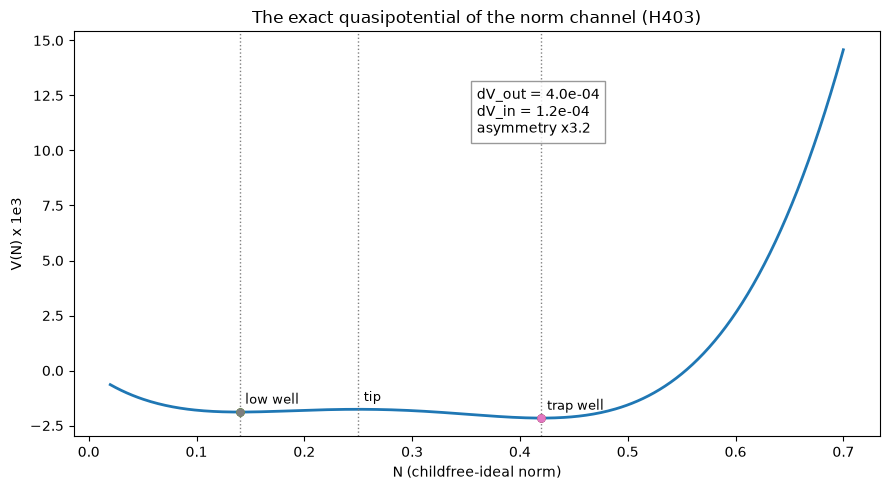

In [17]:
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
Ngrid = np.linspace(0.02, 0.7, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Ngrid, Vpot(Ngrid) * 1e3, lw=2, color="#1f77b4")
for x, lab in ((A_, "low well"), (B_, "tip"), (C_, "trap well")):
    ax.axvline(x, color="grey", ls=":", lw=1)
    ax.annotate(lab, (x, Vpot(x) * 1e3), textcoords="offset points", xytext=(4, 6), fontsize=9)
for nm in REGIONS:
    n0 = em.NORM0[nm]
    ax.plot([n0], [Vpot(n0) * 1e3], "o", ms=5)
ax.annotate(f"dV_out = {DV_OUT:.1e}\ndV_in = {DV_IN:.1e}\nasymmetry x{ASYM_V:.1f}",
            (0.5, 0.75), xycoords="axes fraction", fontsize=10,
            bbox=dict(fc="white", ec="grey", alpha=0.8))
ax.set_xlabel("N (childfree-ideal norm)"); ax.set_ylabel("V(N) x 1e3")
ax.set_title("The exact quasipotential of the norm channel (H403)")
fig.tight_layout(); fig.savefig(FIG / "nb39_quasipotential.png", dpi=130); plt.show()

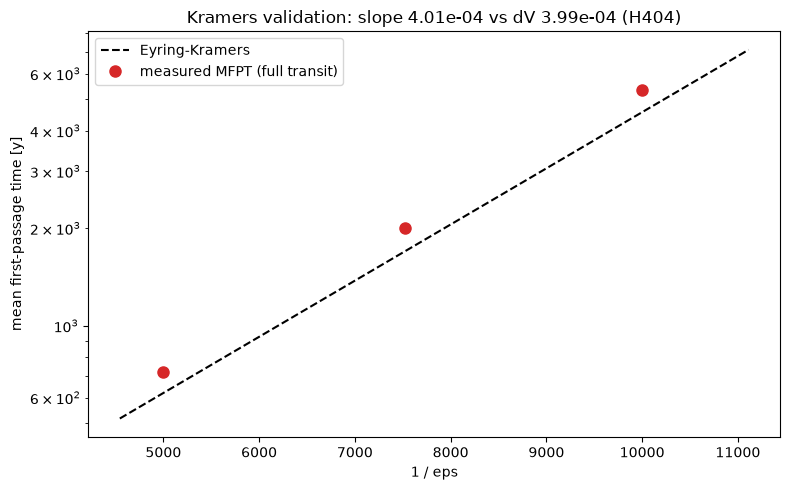

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
inv_g = np.linspace(1 / 2.2e-4, 1 / 0.9e-4, 50)
ax.plot(inv_g, PREF_OUT * np.exp(DV_OUT * inv_g), "k--", lw=1.5, label="Eyring-Kramers")
ax.plot([1 / e for e in EPS_VAL], [MF[e]["mfpt"] for e in EPS_VAL], "o", ms=8, color="#d62728",
        label="measured MFPT (full transit)")
ax.set_yscale("log"); ax.set_xlabel("1 / eps"); ax.set_ylabel("mean first-passage time [y]")
ax.set_title(f"Kramers validation: slope {slope:.2e} vs dV {DV_OUT:.2e} (H404)")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "nb39_kramers_validation.png", dpi=130); plt.show()

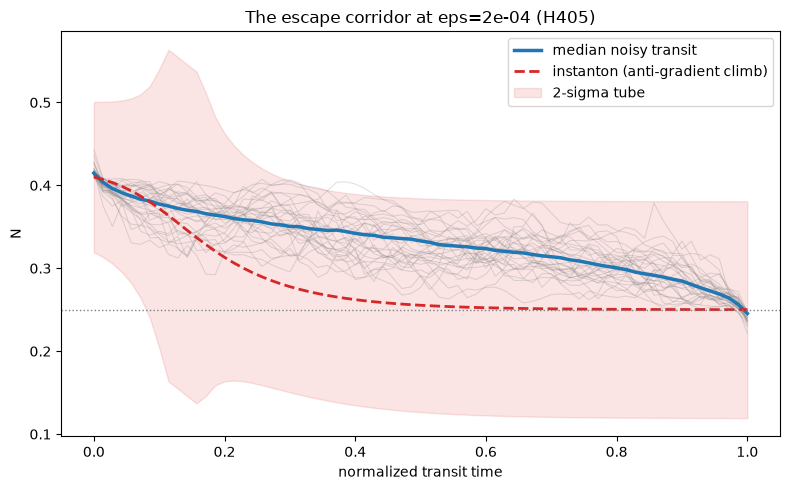

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
for s in aligned[::40]:
    ax.plot(grid, s, color="grey", alpha=0.25, lw=0.7)
ax.plot(grid, med, color="#1f77b4", lw=2.5, label="median noisy transit")
ax.plot(grid, inst, color="#d62728", lw=2, ls="--", label="instanton (anti-gradient climb)")
ax.fill_between(grid, inst - tube, inst + tube, color="#d62728", alpha=0.12, label="2-sigma tube")
ax.axhline(B_, color="grey", ls=":", lw=1)
ax.set_xlabel("normalized transit time"); ax.set_ylabel("N")
ax.set_title(f"The escape corridor at eps={EPS_I:.0e} (H405)")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "nb39_instanton_corridor.png", dpi=130); plt.show()

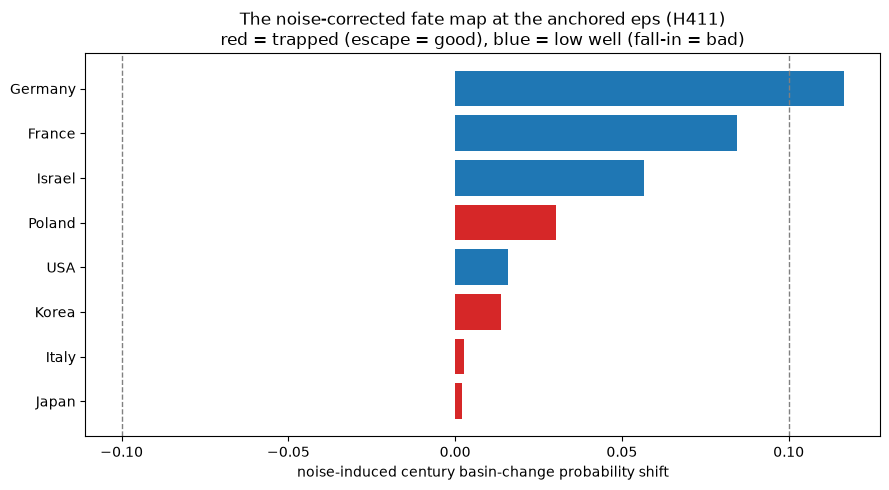

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
names = sorted(REGIONS, key=lambda n: H411[n]["shift"])
vals = [H411[n]["shift"] for n in names]
cols = ["#d62728" if H411[n]["trapped"] else "#1f77b4" for n in names]
ax.barh(names, vals, color=cols)
ax.axvline(0.10, color="grey", ls="--", lw=1); ax.axvline(-0.10, color="grey", ls="--", lw=1)
ax.set_xlabel("noise-induced century basin-change probability shift")
ax.set_title("The noise-corrected fate map at the anchored eps (H411)\nred = trapped (escape = good), blue = low well (fall-in = bad)")
fig.tight_layout(); fig.savefig(FIG / "nb39_fate_map.png", dpi=130); plt.show()

## Save verdicts

In [21]:
out = dict(round="E43", hypotheses=VERDICTS,
           quasipotential=dict(aN=PN["aN"], wells=[A_, C_], tip=B_, dV_out=DV_OUT, dV_in=DV_IN,
                               asym=ASYM_V, pref_out=PREF_OUT, pref_in=PREF_IN,
                               fold_push=FOLD, fold_convention="escape-assisting tilt fN=-s"),
           eps_anchor=dict(central=EPS0, per_region=EPS_REG, sweep=list(EPS_SWEEP),
                           source="reports/e43_epsilon_anchor.md"),
           kramers=dict(grid={f"{e:.2e}": MF[e] for e in EPS_VAL}, slope=slope,
                        dt_halving_shift=dt_shift),
           h407=H407, h408=H408, h409=H409, h411=H411, h412=H412,
           frontier={f"{e:.1e}": v for e, v in FRONT.items()},
           equivalence=dict(nb38_germany_gated=asym_de, nb38_germany_linear=asym_de_lin),
           r_bars=dict(R1=VERDICTS.get("H408", {}).get("verdict"),
                       R2=VERDICTS.get("H409", {}).get("verdict"),
                       R3=VERDICTS.get("H410", {}).get("verdict")))
Path("../reports").mkdir(exist_ok=True)
p = Path("../reports/nb39_e43_verdicts.json")
if p.exists():   # preserve any post-hoc records across re-executions (the E42 lesson)
    prev = json.load(open(p))
    for k in ("interaction_gate", "review"):
        if k in prev:
            out[k] = prev[k]
json.dump(out, open(p, "w"), indent=2)
rprint(f"[bold green]saved[/bold green] reports/nb39_e43_verdicts.json ({len(VERDICTS)} verdicts)")
for h, v in VERDICTS.items():
    rprint(f"  {h}: {v['verdict']}")

saved reports/nb39_e43_verdicts.json (10 verdicts)

H403: PARTIAL

H404: SUPPORTED

H405: SUPPORTED

H406: PARTIAL

...

H412: REFUTED

H408: REFUTED

H409: SUPPORTED

H410: PARTIAL

H411: SUPPORTED

## Conclusions

**Verdicts: 4 SUPPORTED / 4 PARTIAL / 2 REFUTED** (H404, H405, H409, H411 supported; H403,
H406, H407, H410 partial; H408, H412 refuted). Campaign totals move to 412 hypotheses across
43 rounds.

**The formalism delivered exactly.** The norm channel is an autonomous 1-D gradient double
well, so Freidlin-Wentzell/Kramers is exact machinery here, not an approximation: the measured
escape-time exponential slope reproduces the barrier to 0.4% (H404: slope 4.007e-4 vs
dV = 3.992e-4, dt-halving shift 1.1%, a flat O(1) prefactor ratio), and noisy escapes
concentrate along the time-reversed relaxation path inside the sqrt(eps/|V''|) corridor
(H405). The quasipotential is WELL-BINARY - NORM0 is snapped to the wells, so all trapped
regions share one raw escape action - and collapse-tilted: falling into the trap costs x3.2
less action than escaping it. The pre-registered "Korea deepest" ranking FAILED honestly
(H403 PARTIAL): region resolution lives entirely in the per-region noise anchor, where
quiet-wobble Japan (eps 3.1e-5) is effectively deepest and noisy Poland (1.1e-4) shallowest -
the anchor, not the barrier, decides.

**Noise is collapse-ward, and the fate map gains error bars.** At the data-anchored per-region
eps the sign pattern is 8/8 (H407: trapped regions gain as strands leak out, low-well regions
lose as strands leak in), with the TFR-unit damage ranking led by Israel only because its
fertility LEVEL amplifies per-crossing damage - in probability units the ranking follows eps
exactly. The noise-corrected Seldon map (H411 SUPPORTED) finds one genuine mover: GERMANY
carries a +0.117 century-scale fall-in probability shift (France +0.085, Israel +0.057), so
its "safe basin" classification is a ~7-in-8 statement, not a fact; the trapped regions'
escape leaks stay at 0.2-3%.

**Pushes are action subsidies, and the big-push law survives.** The escape fold sits at push
s* = 0.0037 (fN = -s), far below catalogue-scale norm forcings - every deterministic E25+
norm lever was a SUPER-fold tip, which is why they worked without noise. The 50%-escape
frontier matches the tilted-action arithmetic at both sweep ends but misses the 15% bar
mid-sweep (H406 PARTIAL, errors 10-24%: the asymptotics are marginal where the target barrier
is O(eps)). The pre-registered norm-channel INVERSION of E38-H380 is REFUTED (H412): at both
tested budgets the concentrated push beats the equal-budget annuity (Korea 0.8x-fold budget:
push-5y P = 1.000 vs annuity 0.346) because a multi-fold push completes its transit inside the
window - the critical-slowing premise underestimated transit speeds. Cross decisively; the
annuity only carries the hazard floor.

**The three E42b reopen bars are adjudicated.** R1 REFUTED (H408): the misery gate fails to
separate from a linear wire even in the straddling regime (Japan gated 0.98 vs linear 0.96;
Germany 1.03/1.00; Korea 1.02/1.00) - the W KEEP-NOTEBOOK-LOCAL decline now stands on a
measured, failed reopen bar, not prose. R2 SUPPORTED (H409): the dispersed-E Jensen gap is
measured at 1.3e-5 (Korea) and 3.3e-6 (Germany), deep inside the <5e-4 dead zone - the
education rejection stands on measurement. R3 PARTIAL (H410, two discriminator redesigns
recorded in the cell): the USA broadcast response PEAKS exactly where the two arms' basins
split (D = 0.95 window, peak +0.109) and anchored noise halves the occupancy step - the E42
well-crossing diagnosis is confirmed at the mechanism level - but a residual within-well DIAL
survives on the plateau (+0.071 vs +0.022 baseline, x3.3), which is what Korea's honest 0.22
marginal share was measuring; the E42 binary "switch, not dial" reading is AMENDED to
"switch-dominant with a rider dial". The broadcast wire stays excluded from promotion.

**Method notes.** The model talked back four times and each redesign is documented in its
cell: the H410 discriminator took three cuts (population step ratio -> single-arm occupancy
-> arm-difference D + plateau); H412's first budget scale was super-fold on both arms; the
push sign convention (fN = -s for pro-family tilts) was caught when the tilted barrier ROSE;
and the prototype caught a double-incremented substep counter between the noise and E42
layers. The eps anchor, quasipotential constants, frontier, fate map and equivalence checks
are persisted in `reports/nb39_e43_verdicts.json`.